Data Preprocessing

In [1]:
#imports for data preprocessing
import pandas as pd
import re

In [2]:
#load data from csv to notebook
data = pd.read_csv("sentiment_analysis.csv")

In [3]:
#function that removes uneccessary charecters and processes white space for model preparation
def textProcessing(text):
  text = re.sub(r"[^\w\s.,!?]", " ", text)
  text = re.sub(r"\s+", " ", text).strip()
  return text

In [4]:
#edit original dataframe to include values for sentiments and cleaned data
data["processedText"] = data["text"].apply(textProcessing)
sentimentValues = {"positive" : 2, "negative" : 0, "neutral" : 1}
data["valueLabel"] = data["sentiment"].str.strip().map(sentimentValues)
print(data[["processedText", "sentiment", "valueLabel"]])

                                         processedText sentiment  valueLabel
0                What a great day!!! Looks like dream.  positive           2
1       I feel sorry, I miss you here in the sea beach  positive           2
2                                       Don t angry me  negative           0
3    We attend in the class just for listening teac...  negative           0
4                    Those who want to go, let them go  negative           0
..                                                 ...       ...         ...
494  According to , a quarter of families under six...  negative           0
495      the plan to not spend money is not going well  negative           0
496    uploading all my bamboozle pictures of facebook   neutral           1
497  congratulations ! you guys finish a month earl...  positive           2
498  actually, I wish I was back in Tahoe. I miss i...  negative           0

[499 rows x 3 columns]


BERT

In [5]:
#imports
import pandas as pd
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [6]:
#tokenize data for BERT
xVals = data['processedText']
yVals = data['valueLabel']
xT, xTest, yT, yTest = train_test_split(xVals, yVals, test_size = 0.2, stratify = yVals, random_state = 42)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
xEncoded = tokenizer.batch_encode_plus(xT.tolist(), padding = True, truncation = True, max_length = 64, return_tensors = 'tf')
xTestEncoded = tokenizer.batch_encode_plus(xTest.tolist(), padding = True, truncation = True, max_length = 64, return_tensors = 'tf')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [7]:
#BERT model code
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = 3)
optim = tf.keras.optimizers.Adam(learning_rate = 2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
met = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer = optim, loss = loss, metrics = [met])
fittingModel = model.fit([xEncoded['input_ids'], xEncoded['token_type_ids'], xEncoded['attention_mask']],
                         yT,
                         batch_size = 8,
                         epochs = 7,
                         validation_split = 0.2)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/7
40/40 [==============================] - 51s 177ms/step - loss: 1.1350 - accuracy: 0.3824 - val_loss: 1.1108 - val_accuracy: 0.3125
Epoch 2/7
40/40 [==============================] - 4s 98ms/step - loss: 1.0340 - accuracy: 0.4828 - val_loss: 1.0303 - val_accuracy: 0.4875
Epoch 3/7
40/40 [==============================] - 3s 78ms/step - loss: 0.9136 - accuracy: 0.5987 - val_loss: 0.9347 - val_accuracy: 0.5000
Epoch 4/7
40/40 [==============================] - 3s 73ms/step - loss: 0.7544 - accuracy: 0.6771 - val_loss: 0.8667 - val_accuracy: 0.5375
Epoch 5/7
40/40 [==============================] - 3s 69ms/step - loss: 0.5482 - accuracy: 0.8150 - val_loss: 0.6697 - val_accuracy: 0.7250
Epoch 6/7
40/40 [==============================] - 3s 67ms/step - loss: 0.3260 - accuracy: 0.9028 - val_loss: 0.8907 - val_accuracy: 0.6750
Epoch 7/7
40/40 [==============================] - 2s 61ms/step - loss: 0.1884 - accuracy: 0.9561 - val_loss: 0.7814 - val_accuracy: 0.7375


BERT Evaluation

In [8]:
#BERT evaluation code
testingVals = model.evaluate([xTestEncoded['input_ids'], xTestEncoded['token_type_ids'], xTestEncoded['attention_mask']],
                         yTest)

print("Testing Loss:")
print(testingVals[0])
print("Testing Accuracy:")
print(testingVals[1])

preds = model.predict([xTestEncoded['input_ids'], xTestEncoded['token_type_ids'], xTestEncoded['attention_mask']])
predLabels = tf.argmax(preds.logits, axis = 1).numpy()
print(classification_report(yTest, predLabels, target_names = ['Negative', 'Neutral', 'Positive']))


4/4 [==============================] - 3s 29ms/step - loss: 0.7740 - accuracy: 0.7400
Testing Loss:
0.7739905714988708
Testing Accuracy:
0.7400000095367432
4/4 [==============================] - 3s 27ms/step
              precision    recall  f1-score   support

    Negative       0.79      0.56      0.65        27
     Neutral       0.73      0.75      0.74        40
    Positive       0.72      0.88      0.79        33

    accuracy                           0.74       100
   macro avg       0.75      0.73      0.73       100
weighted avg       0.75      0.74      0.73       100



BERT Model Visualizations

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plotter
import seaborn as s

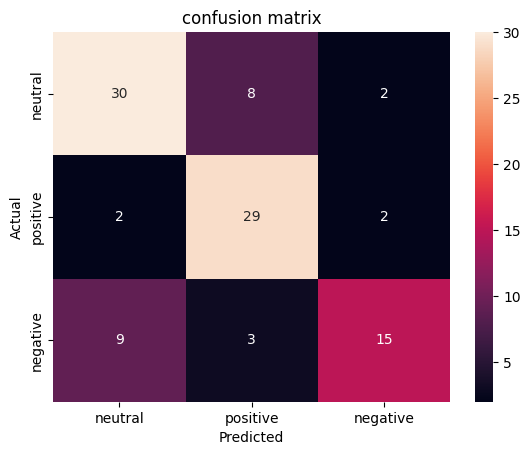

In [12]:
#confusion matrix
sentimentVal = {2: "positive", 0: "negative", 1: "neutral"}
og = [sentimentVal[l] for l in yTest.tolist()]
predss = [sentimentVal[l] for l in predLabels]
conMat = confusion_matrix(og, predss, labels = ['neutral', 'positive', 'negative'])
s.heatmap(conMat, annot = True, xticklabels = ['neutral', 'positive', 'negative'], yticklabels = ['neutral', 'positive', 'negative'])
plotter.xlabel("Predicted")
plotter.ylabel("Actual")
plotter.title("confusion matrix")
plotter.show()

In [13]:
incorrects = []
print("Actual       Pred.      String")
for i in range(len(og)):
  if og[i] != predss[i]:
    incorrects.append((og[i], predss[i], data.iloc[i]['processedText']))
for i in range(5):
  print(incorrects[i])



Actual       Pred.      String
('negative', 'positive', 'Both of you')
('negative', 'neutral', 'Love is something like E MC 2 rules')
('positive', 'neutral', 'i want to go to music tonight but i lost my voice.')
('neutral', 'negative', 'I m in the village now and there hardly found internate, feeling gloomy')
('negative', 'neutral', 'juss came back from Barisal')


RoBERTa

In [14]:
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification
tok2 = RobertaTokenizer.from_pretrained('roberta-base')
encTrain = tok2.batch_encode_plus(xT.tolist(), padding=True, truncation=True, max_length=64, return_tensors='tf')
encTest = tok2.batch_encode_plus(xTest.tolist(), padding=True, truncation=True, max_length=64, return_tensors='tf')

rModel = TFRobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)
rModel.compile(optimizer=tf.keras.optimizers.Adam(2e-5),
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=[tf.keras.metrics.SparseCategoricalAccuracy('accuracy')])

rModel.fit([encTrain['input_ids'], encTrain['attention_mask']],
           yT,
           batch_size=8,
           epochs=7,
           validation_split=0.2)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

Epoch 1/7
40/40 [==============================] - 49s 211ms/step - loss: 1.1016 - accuracy: 0.3699 - val_loss: 1.1098 - val_accuracy: 0.3625
Epoch 2/7
40/40 [==============================] - 4s 106ms/step - loss: 1.0716 - accuracy: 0.4169 - val_loss: 1.1133 - val_accuracy: 0.4625
Epoch 3/7
40/40 [==============================] - 3s 88ms/step - loss: 0.9550 - accuracy: 0.5423 - val_loss: 0.8297 - val_accuracy: 0.6250
Epoch 4/7
40/40 [==============================] - 3s 75ms/step - loss: 0.5735 - accuracy: 0.7962 - val_loss: 0.7746 - val_accuracy: 0.6750
Epoch 5/7
40/40 [==============================] - 3s 73ms/step - loss: 0.3268 - accuracy: 0.8966 - val_loss: 0.6213 - val_accuracy: 0.7125
Epoch 6/7
40/40 [==============================] - 2s 59ms/step - loss: 0.1791 - accuracy: 0.9467 - val_loss: 0.6750 - val_accuracy: 0.7750
Epoch 7/7
40/40 [==============================] - 3s 71ms/step - loss: 0.0888 - accuracy: 0.9749 - val_loss: 0.7450 - val_accuracy: 0.7500


RoBERTa Evaluation

4/4 [==============================] - 3s 27ms/step - loss: 0.7657 - accuracy: 0.7500
Loss: 0.7656669020652771
Acc: 0.75
4/4 [==============================] - 3s 25ms/step
              precision    recall  f1-score   support

    Negative       0.88      0.56      0.68        27
     Neutral       0.67      0.90      0.77        40
    Positive       0.83      0.73      0.77        33

    accuracy                           0.75       100
   macro avg       0.79      0.73      0.74       100
weighted avg       0.78      0.75      0.75       100



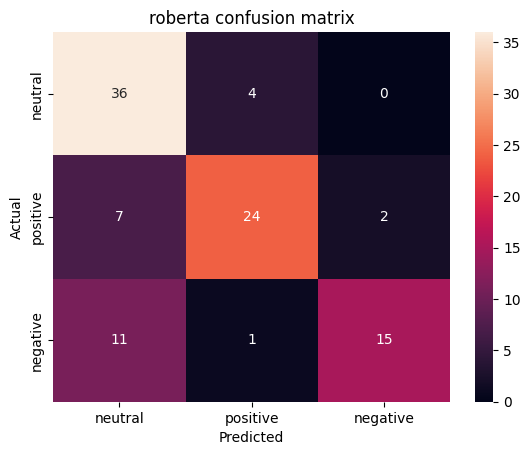

('neutral', 'positive', 'Its night 2 am, feeling neutral')
('negative', 'neutral', 'Love is something like E MC 2 rules')
('positive', 'neutral', 'My Sharpie is running DANGERously low on ink')
('positive', 'neutral', 'i want to go to music tonight but i lost my voice.')
('negative', 'positive', 'Always somewhere I miss you where I have been')


In [15]:
ev = rModel.evaluate([encTest['input_ids'], encTest['attention_mask']], yTest)
print("Loss:", ev[0])
print("Acc:", ev[1])

rPred = rModel.predict([encTest['input_ids'], encTest['attention_mask']])
rLab = tf.argmax(rPred.logits, axis=1).numpy()
print(classification_report(yTest, rLab, target_names=['Negative', 'Neutral', 'Positive']))

sentMap = {2: 'positive', 0: 'negative', 1: 'neutral'}
orig = [sentMap[i] for i in yTest.tolist()]
preds = [sentMap[i] for i in rLab]
cm2 = confusion_matrix(orig, preds, labels=['neutral', 'positive', 'negative'])
s.heatmap(cm2, annot=True, xticklabels=['neutral', 'positive', 'negative'],
          yticklabels=['neutral', 'positive', 'negative'])
plotter.xlabel("Predicted")
plotter.ylabel("Actual")
plotter.title("roberta confusion matrix")
plotter.show()
#Examples of Incorrect Predictions

wrong = []
for i in range(len(orig)):
    if orig[i] != preds[i]:
        wrong.append((orig[i], preds[i], data.iloc[i]['processedText']))
for i in range(min(5, len(wrong))):
    print(wrong[i])

Logistic Regression

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

X_text = data['processedText']
y = data['valueLabel']

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



Logistic Regression Evaluation

Accuracy: 0.65
F1 Score: 0.6591071428571428


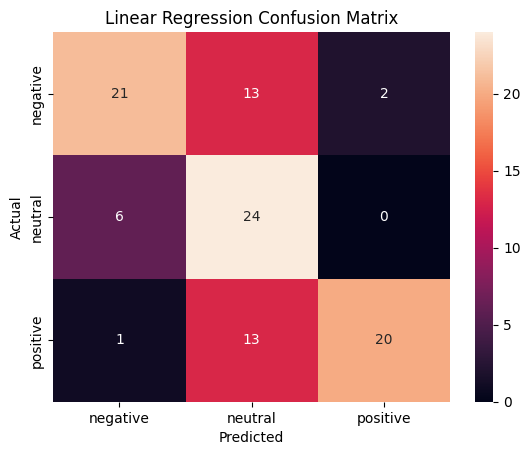

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.58      0.66        36
     neutral       0.48      0.80      0.60        30
    positive       0.91      0.59      0.71        34

    accuracy                           0.65       100
   macro avg       0.71      0.66      0.66       100
weighted avg       0.72      0.65      0.66       100

(1, np.int64(0), 'What a great day!!! Looks like dream.')
(2, np.int64(0), 'Don t angry me')
(0, np.int64(1), 'Soooo high')
(2, np.int64(1), 'Both of you')
(2, np.int64(1), 'Today first time I arrive in the boat. Its amazing journey')


In [33]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True,
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Linear Regression Confusion Matrix')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))
#Examples of Incorrect Predictions

wrong = []
y_test = y_test.tolist()
for i in range(len(y_test)):
    if y_test[i] != y_pred[i]:
        wrong.append((y_test[i], y_pred[i], data.iloc[i]['processedText']))
for i in range(min(5, len(wrong))):
    print(wrong[i])

Naive Bayes

Importing necessary libraries for Naive Bayes implementation

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import numpy as np
from collections import Counter
from matplotlib import pyplot as plt

In [35]:
Xtrain,Xtest,ytrain,ytest=train_test_split(data['processedText'],data['valueLabel'],test_size=0.2,random_state=42)
vectorizer=CountVectorizer()
XtrainVect = vectorizer.fit_transform(Xtrain)
XtestVect = vectorizer.transform(Xtest)
#trraining the naive bayes model
naivebayes = MultinomialNB()
naivebayes.fit(XtrainVect,ytrain)
#predicting
pred = naivebayes.predict(XtestVect)

Naive Bayes Evaluation

accuracy: 0.64
              precision    recall  f1-score   support

    negative       0.81      0.47      0.60        36
     neutral       0.52      0.80      0.63        30
    positive       0.70      0.68      0.69        34

    accuracy                           0.64       100
   macro avg       0.68      0.65      0.64       100
weighted avg       0.68      0.64      0.64       100



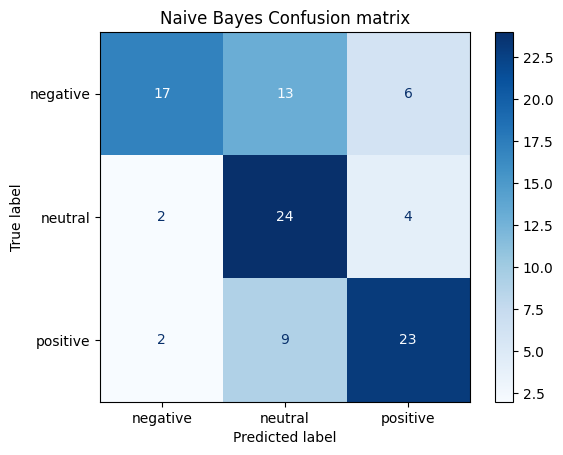

In [38]:

accuracy = accuracy_score(ytest,pred)
#testing accuracy
print("accuracy: " + str(accuracy))
#classification report
print(classification_report(ytest,pred,target_names=['negative','neutral','positive']))
#confusion matrix
cm=confusion_matrix(ytest,pred,labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['negative','neutral','positive'])
disp.plot(cmap='Blues')
plt.title('Naive Bayes Confusion matrix')
plt.show()

In [39]:

#Examples of Incorrect Predictions
wrong = []
ytest = ytest.tolist()
for i in range(len(ytest)):
    if ytest[i] != pred[i]:
        wrong.append((ytest[i], pred[i], data.iloc[i]['processedText']))
for i in range(min(5, len(wrong))):
    print(wrong[i])

(1, np.int64(2), 'What a great day!!! Looks like dream.')
(2, np.int64(1), 'Don t angry me')
(0, np.int64(1), 'Soooo high')
(2, np.int64(1), 'Both of you')
(0, np.int64(2), 'Love is something like E MC 2 rules')


Baseline Comparison

In [40]:
majorityclass = Counter(ytrain).most_common(1)
#print(majorityclass)
majorityclass = majorityclass[0][0]
majorityPreds = [majorityclass]*len(ytest)
mAcc = accuracy_score(ytest,majorityPreds)
print('Baseline accuracy: ' + str(mAcc))

Baseline accuracy: 0.3


accuracy: 0.3
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        36
     neutral       0.30      1.00      0.46        30
    positive       0.00      0.00      0.00        34

    accuracy                           0.30       100
   macro avg       0.10      0.33      0.15       100
weighted avg       0.09      0.30      0.14       100



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


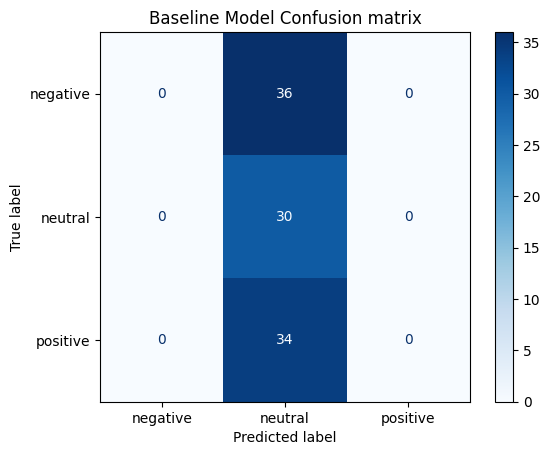

In [41]:
accuracy = accuracy_score(ytest,majorityPreds)
#testing accuracy
print("accuracy: " + str(accuracy))
#classification report
print(classification_report(ytest,majorityPreds,target_names=['negative','neutral','positive']))
#confusion matrix
cm=confusion_matrix(ytest,majorityPreds,labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['negative','neutral','positive'])
disp.plot(cmap='Blues')
plt.title('Baseline Model Confusion matrix')
plt.show()

In [43]:
#Examples of Incorrect Predictions
wrong = []
for i in range(len(ytest)):
    if ytest[i] != majorityPreds[i]:
        wrong.append((ytest[i], majorityPreds[i], data.iloc[i]['processedText']))
for i in range(min(5, len(wrong))):
    print(wrong[i])

(2, 1, 'Don t angry me')
(0, 1, 'Its night 2 am, feeling neutral')
(0, 1, 'Soooo high')
(2, 1, 'Both of you')
(2, 1, 'Today first time I arrive in the boat. Its amazing journey')
